In [ ]:
!pip install google-play-scraper
from google_play_scraper import reviews, Sort
import pandas as pd

!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Scrape Flutterwave Mobile
fw_result, _ = reviews(
    'com.flutterwave.app',
    lang='en',
    country='ng',
    sort=Sort.NEWEST,
    count=5000
)

# Scrape Send App
send_result, _ = reviews(
    'com.flutterwave.send.prod',
    lang='en',
    sort=Sort.NEWEST,
    count=5000
)

##Creating a dataset
fw_df = pd.DataFrame(fw_result)[['content','score','at']].dropna()
send_df = pd.DataFrame(send_result)[['content','score','at']].dropna()

##assianging the sentiment score
for df in [fw_df, send_df]:
    df['sentiment_score'] = df['content'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
    df['sentiment_label'] = df['sentiment_score'].apply(lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral'))

##understanding the dataset
print("Flutterwave Mobile:", fw_df.shape)
print(fw_df['sentiment_label'].value_counts())
print("\nSend App:", send_df.shape)
print(send_df['sentiment_label'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.9 MB/s eta 0:00:00
Flutterwave Mobile: (1846, 5)
sentiment_label
Positive    1169
Negative     417
Neutral      260
Name: count, dtype: int64

Send App: (1483, 5)
sentiment_label
Positive    737
Negative    460
Neutral     286
Name: count, dtype: int64


In [ ]:
# Get average ratings
print(f"Flutterwave Mobile avg rating: {fw_df['score'].mean():.2f}")
print(f"Send App avg rating: {send_df['score'].mean():.2f}")

# Sample negative reviews
print("\nFLUTTERWAVE MOBILE - NEGATIVE SAMPLE:")
print(fw_df[fw_df['sentiment_label']=='Negative']['content'].sample(15).tolist())

print("\nSEND APP - NEGATIVE SAMPLE:")
print(send_df[send_df['sentiment_label']=='Negative']['content'].sample(15).tolist())

print("\nFLUTTERWAVE MOBILE - POSITIVE SAMPLE:")
print(fw_df[fw_df['sentiment_label']=='Positive']['content'].sample(10).tolist())

Flutterwave Mobile avg rating: 3.26
Send App avg rating: 2.95

FLUTTERWAVE MOBILE - NEGATIVE SAMPLE:
['Worst fintech in Nigeria, they have a porous system that keeps getting worst, then go to the Nigerian police to harass merchahts', "Looks like merchant's will now be required to take a plane to Nigeria to go and collect thier payouts. Nothing works !!! Am using flutterwave to collect payments. Now its months and I can't transfer funds. The funds are just there in my account but whenever I try to transfer, the otp fails. What's the point of collecting payments then holding them without reason. Am a developer too and for the past few months I have learned that this is not a development issue. Something dirty is going on", "Loading takes time I can't comfortably use the app tho my net is fast", "The platform doesn't allow Nigerians transact but other people in other countries can", 'Scam', 'So bad I regret 😪 having or opening 😫 😪 dis account 😫', "The one issue I've always had with this a

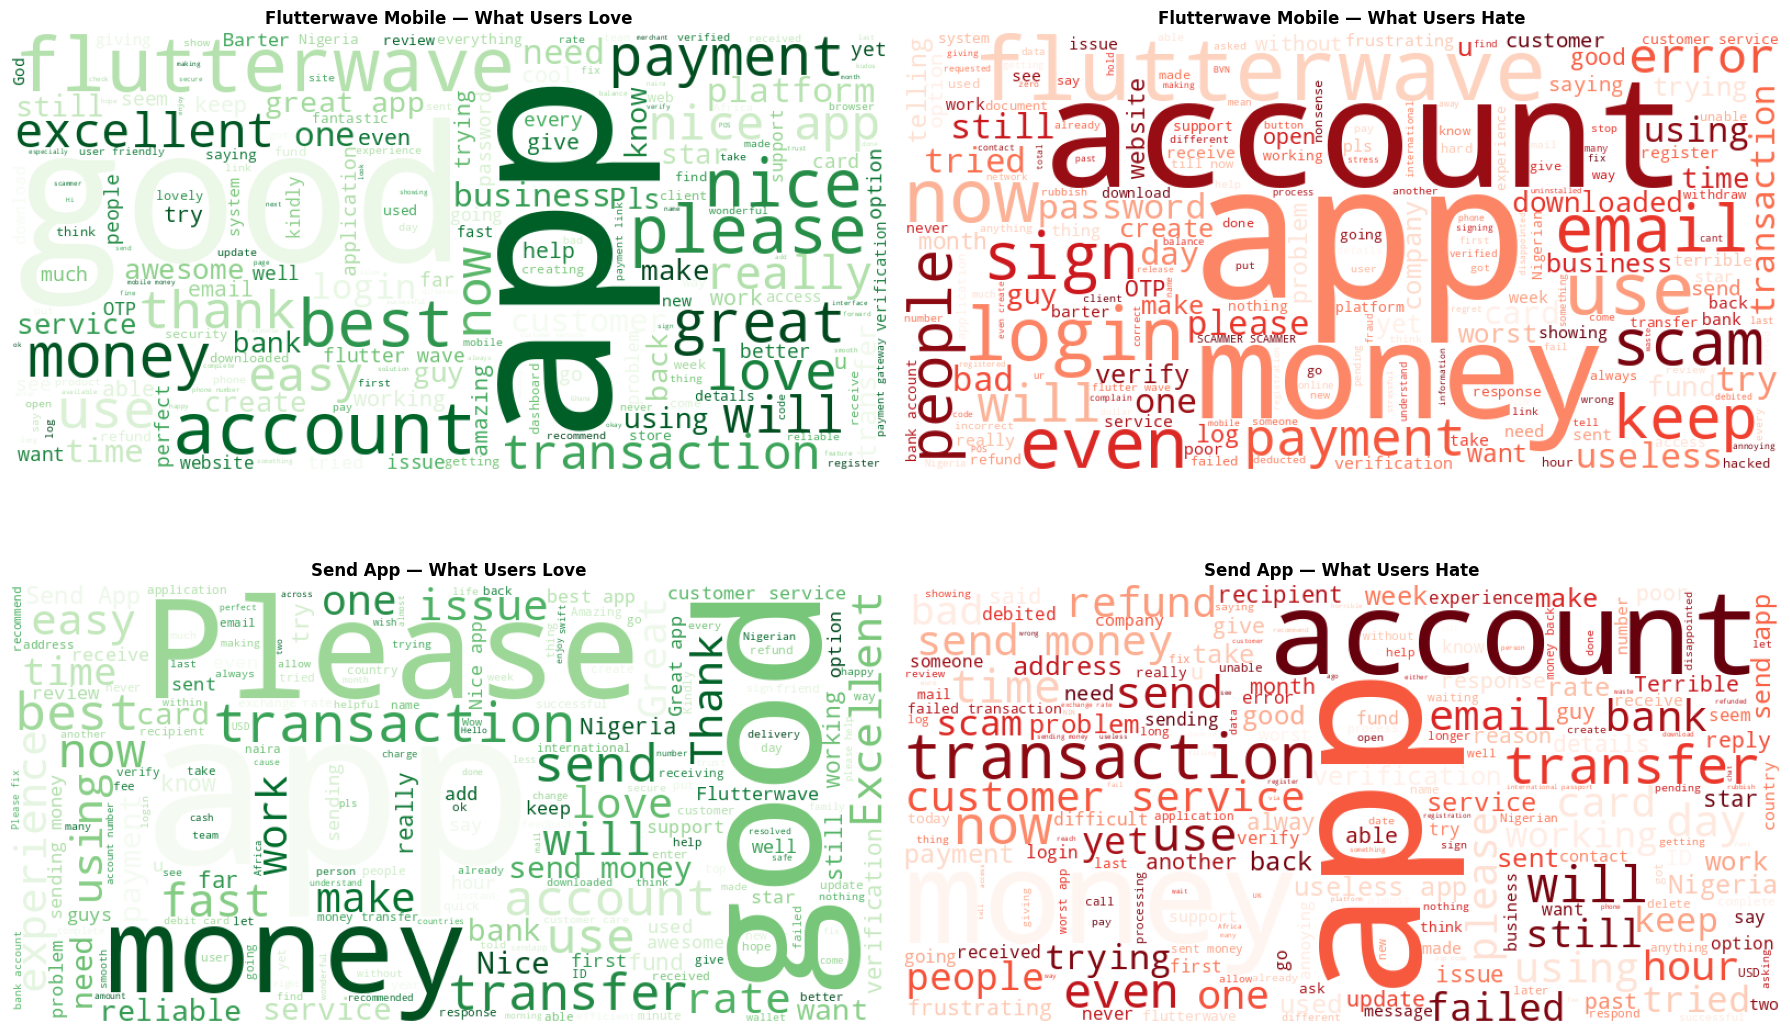

Flutterwave Mobile vs Send App — U: 1531953, P: 0.00000, Significant: True


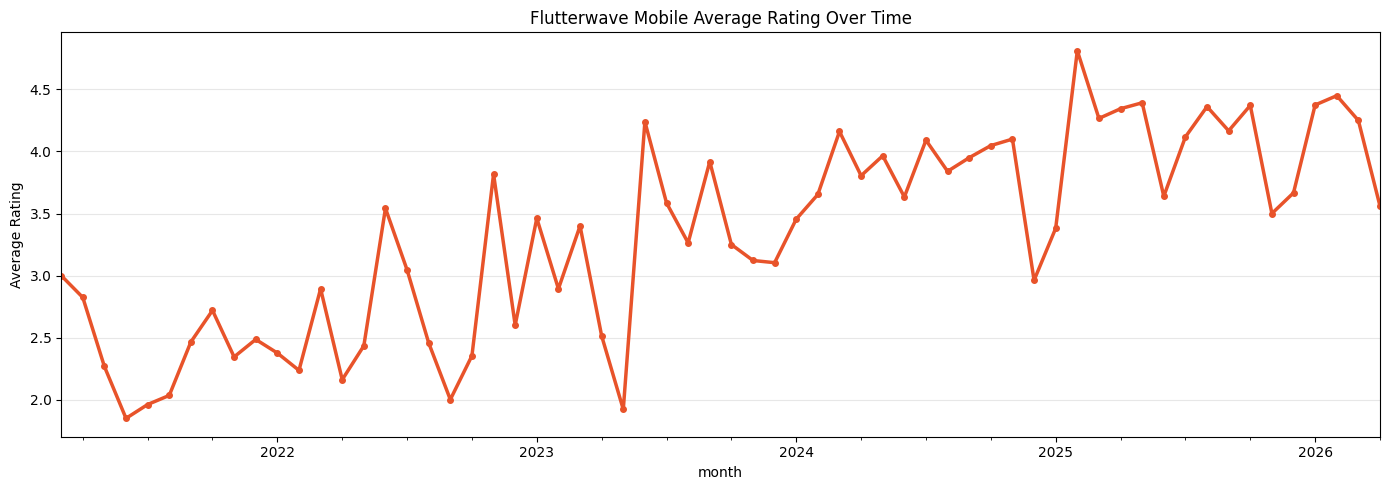

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from scipy.stats import mannwhitneyu

# Word clouds
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Flutterwave Mobile
fw_pos = ' '.join(fw_df[fw_df['sentiment_label']=='Positive']['content'])
fw_neg = ' '.join(fw_df[fw_df['sentiment_label']=='Negative']['content'])

axes[0,0].imshow(WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(fw_pos))
axes[0,0].set_title('Flutterwave Mobile — What Users Love', fontweight='bold')
axes[0,0].axis('off')

axes[0,1].imshow(WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(fw_neg))
axes[0,1].set_title('Flutterwave Mobile — What Users Hate', fontweight='bold')
axes[0,1].axis('off')

# Send App
send_pos = ' '.join(send_df[send_df['sentiment_label']=='Positive']['content'])
send_neg = ' '.join(send_df[send_df['sentiment_label']=='Negative']['content'])

axes[1,0].imshow(WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(send_pos))
axes[1,0].set_title('Send App — What Users Love', fontweight='bold')
axes[1,0].axis('off')

axes[1,1].imshow(WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(send_neg))
axes[1,1].set_title('Send App — What Users Hate', fontweight='bold')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('flutterwave_wordclouds.png', dpi=300)
plt.show()

# Mann Whitney between both apps
u, p = mannwhitneyu(fw_df['sentiment_score'], send_df['sentiment_score'])
print(f"Flutterwave Mobile vs Send App — U: {u:.0f}, P: {p:.5f}, Significant: {p < 0.05}")

# Rating trend
fw_df['at'] = pd.to_datetime(fw_df['at'])
fw_df['month'] = fw_df['at'].dt.to_period('M')
fw_df.groupby('month')['score'].mean().plot(
    kind='line', color='#E8532A', linewidth=2.5,
    marker='o', markersize=4, figsize=(14,5),
    title='Flutterwave Mobile Average Rating Over Time'
)
plt.ylabel('Average Rating')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('flutterwave_rating_trend.png', dpi=300)
plt.show()